# 1.2. DataPrep: Cmax values

### 📘 Overview

This notebook compiles manually curated C<sub>max</sub> values from 20+ studies to assign a consensus median C<sub>max</sub> value for each compound.

**Inputs**
- Manually collected C<sub>max</sub> data from clinical and preclinical studies  
- Compound names for alignment and deduplication

**Output**  
A CSV file containing:  
- Compound names  
- All collected C<sub>max</sub> values  
- Median consensus C<sub>max</sub> per compound

In [1]:
%%capture

!pip install openpyxl

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import dilimap as dmap

In [3]:
dmap.logging.print_version()

Running dilimap 1.0.3 (python 3.11.8) on 2025-10-07 10:32.


## Compile consensus median Cmax from various studies

In [4]:
kwargs = {'header': 1, 'index_col': 0}

df = dmap.s3.read('compound_Cmax_values.xlsx', sheet_name='CMAX (master)', **kwargs)
df_free = dmap.s3.read('compound_Cmax_values.xlsx', sheet_name='free CMAX', **kwargs)

Package: s3://dilimap/public/data. Top hash: e5bf3de9d2
Package: s3://dilimap/public/data. Top hash: e5bf3de9d2


In [5]:
df.loc[:, 'NCATS':'Manual'].head()

,NCATS,Porceddu12,Khetani13,Persson13,Aleo14,Garside14,Gustafsson14,Chen14,Shah15,Camenisch19,Dixit19,Aleo20,Williams20,Smit20,Manual
LIBRARY CMPDS,,,,,,,,,,,,,,,
Abacavir,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.90,14.8,14.90,14.31902,NaN,NaN,9.918279,19.068241
Acarbose,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.15,NaN,NaN,NaN,NaN,0.075897
Acebutolol,0.273463,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.27,1.39000,NaN,NaN,5.944773,2.737568
Aceclofenac,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,39.43000,NaN,NaN,NaN,21.457410
Acetaminophen,NaN,130.0,NaN,NaN,NaN,165.387669,165.4,132.31,NaN,NaN,NaN,NaN,165.384393,117.094469,45.646997


In [ ]:
df['Cmax_median'] = df.loc[:, 'NCATS':'Manual'].median(axis=1, skipna=True)
df['Cmax_std'] = '+/- ' + df.loc[:, 'NCATS':'Manual'].std(axis=1, skipna=True).round(
    4
).astype(str)

In [18]:
df['free_Cmax_median'] = df_free['free_Cmax_median'] = df_free.loc[:, 'Garside14':'Dixit19'].median(axis=1, skipna=True)
df['free_Cmax_std'] = df_free['free_Cmax_std'] = '+/- ' + df_free.loc[:, 'Garside14':'Dixit19'].std(
    axis=1, skipna=True
).round(4).astype(str)

## Visualize

In [29]:
# Drop NaNs and zeros
df_filtered = df.dropna(subset=['Cmax_median', 'free_Cmax_median']).copy()
df_filtered = df_filtered[
    (df_filtered['Cmax_median'] > 0) & (df_filtered['free_Cmax_median'] > 0)
]

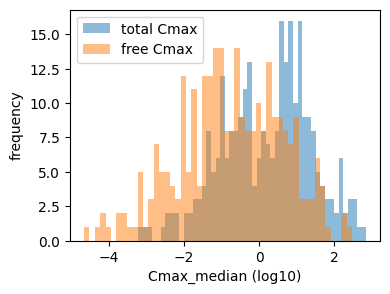

In [30]:
plt.subplots(figsize=(4, 3))
plt.hist(np.log10(df_filtered['Cmax_median']), alpha=0.5, bins=50, label='total Cmax')
plt.hist(np.log10(df_filtered['free_Cmax_median']), alpha=0.5, bins=50, label='free Cmax')
plt.xlabel('Cmax_median (log10)')
plt.ylabel('frequency')
plt.legend()

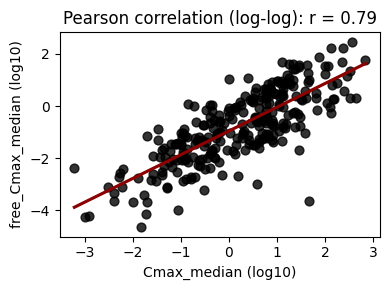

In [31]:
from scipy.stats import pearsonr

# Compute Pearson correlation on log-transformed values
log_x = np.log10(df_filtered['Cmax_median'])
log_y = np.log10(df_filtered['free_Cmax_median'])
r, p_value = pearsonr(log_x, log_y)

# Plot
plt.figure(figsize=(4, 3))
sns.regplot(
    x=log_x, y=log_y, ci=None, color='darkred', scatter_kws={'s': 40, 'color': 'k'}
)

plt.xlabel('Cmax_median (log10)')
plt.ylabel('free_Cmax_median (log10)')
plt.title(f'Pearson correlation (log-log): r = {r:.2f}')
plt.tight_layout()
plt.show()

## Push file to S3

In [27]:
df.to_csv('total_Cmax.csv')
df_free.to_csv('free_Cmax.csv')

In [ ]:
# dmap.s3.write(df, 'compound_Cmax_values.csv')

Package: s3://dilimap/public/data. Top hash: e5bf3de9d2


Copying objects: 100%|██████████| 58.3k/58.3k [00:01<00:00, 54.2kB/s]


Package public/data@155a2b3 pushed to s3://dilimap
Run `quilt3 catalog s3://dilimap/` to browse.
Successfully pushed the new package
